# Bivariate Analysis

## Objective

In this notebook, I explore the relationship between different features in the dataset. The goal is to understand how one variable influences another and identify patterns that can provide meaningful business insights.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

hotel_df = pd.read_csv("../data/hotel_bookings_cleaned.csv")

Analysis 1 : Booking Cancellation Analysis

## Booking Cancellation Analysis

### Why am I analyzing this?

Booking cancellations directly affect hotel revenue and occupancy. In this section, I compare cancellations across hotel types and deposit policies to understand the factors associated with cancelled bookings.

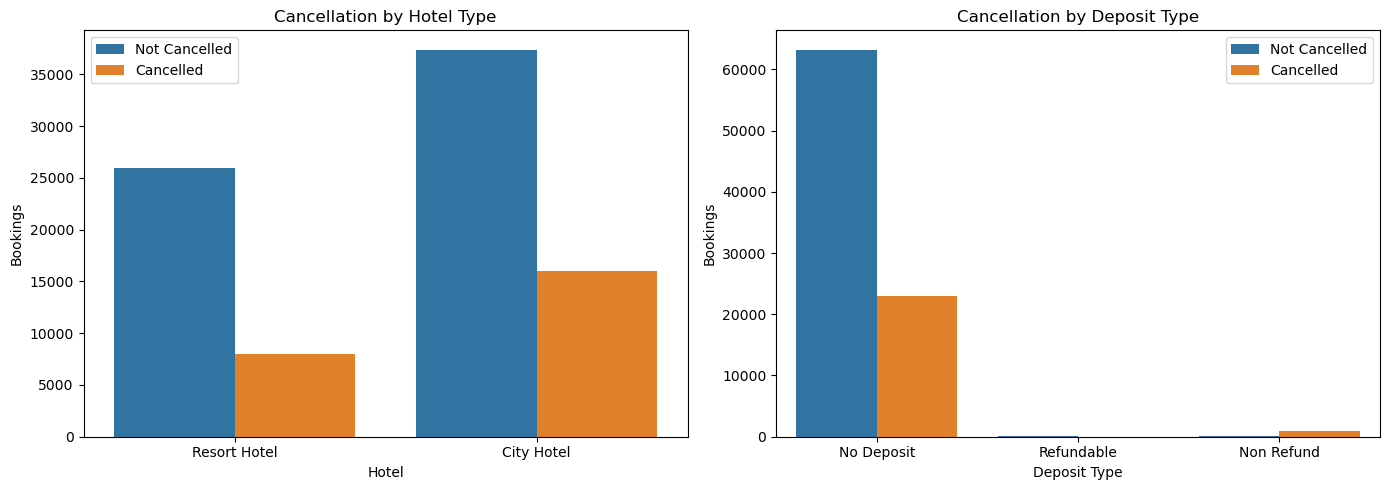

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=hotel_df,
    x="hotel",
    hue="is_canceled",
    ax=axes[0]
)

axes[0].set_title("Cancellation by Hotel Type")
axes[0].set_xlabel("Hotel")
axes[0].set_ylabel("Bookings")
axes[0].legend(["Not Cancelled", "Cancelled"])

sns.countplot(
    data=hotel_df,
    x="deposit_type",
    hue="is_canceled",
    ax=axes[1]
)

axes[1].set_title("Cancellation by Deposit Type")
axes[1].set_xlabel("Deposit Type")
axes[1].set_ylabel("Bookings")
axes[1].legend(["Not Cancelled", "Cancelled"])

plt.tight_layout()
plt.savefig(
    "../visuals/cancellation_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Cancellation behavior differs across hotel types and deposit policies. Some categories show a noticeably higher number of cancelled bookings than others.

### Insight

These patterns suggest that hotel type and deposit policy are important factors associated with booking cancellations. Understanding these relationships can help hotels improve booking policies and reduce revenue loss.

Room Pricing Analysis

## Room Pricing Analysis

### Why am I analyzing this?

The Average Daily Rate (ADR) represents the average revenue earned per occupied room. Comparing ADR across hotel types and market segments helps identify pricing differences among customer groups.

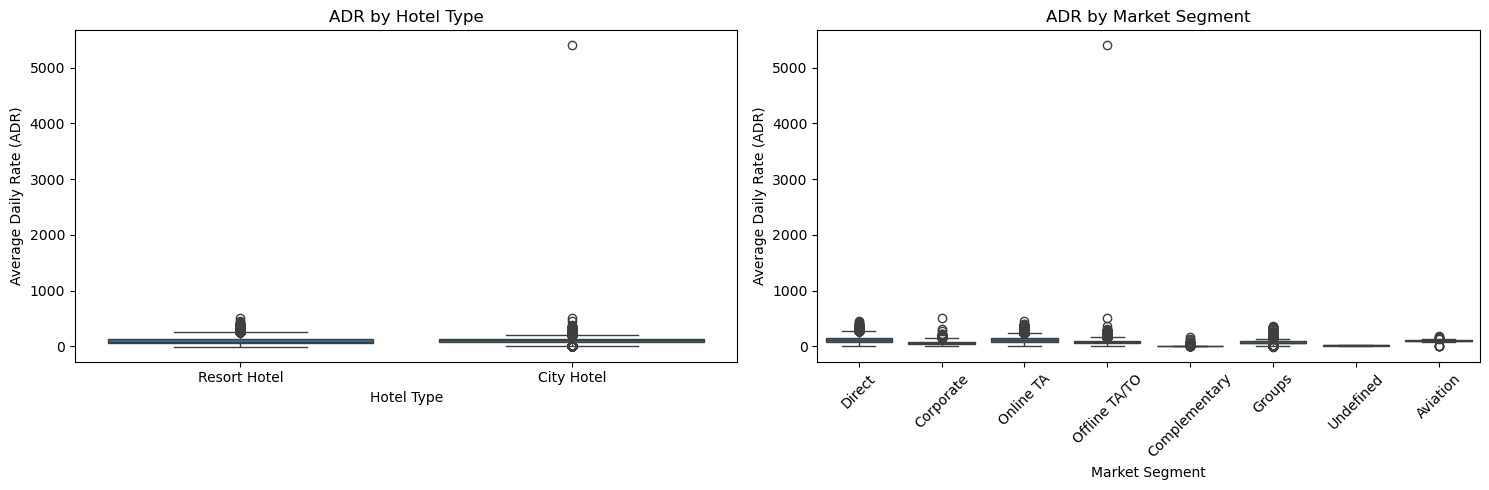

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=hotel_df,
    x="hotel",
    y="adr",
    ax=axes[0]
)

axes[0].set_title("ADR by Hotel Type")
axes[0].set_xlabel("Hotel Type")
axes[0].set_ylabel("Average Daily Rate (ADR)")

sns.boxplot(
    data=hotel_df,
    x="market_segment",
    y="adr",
    ax=axes[1]
)

axes[1].set_title("ADR by Market Segment")
axes[1].set_xlabel("Market Segment")
axes[1].set_ylabel("Average Daily Rate (ADR)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig("../visuals/adr_hotel_market_segment.png", dpi=150)
plt.show()

### Observation

Room prices vary across hotel types and market segments. Some market segments have a wider spread of ADR values, indicating greater variation in booking prices.

### Insight

Comparing ADR across customer segments helps identify high-value markets and supports more effective pricing and revenue management strategies.

## Customer Booking Behaviour

### Why am I analyzing this?

Booking behavior can provide useful insights into customer commitment. In this section, I compare lead time and the number of special requests with booking status to understand how these factors relate to cancellations.

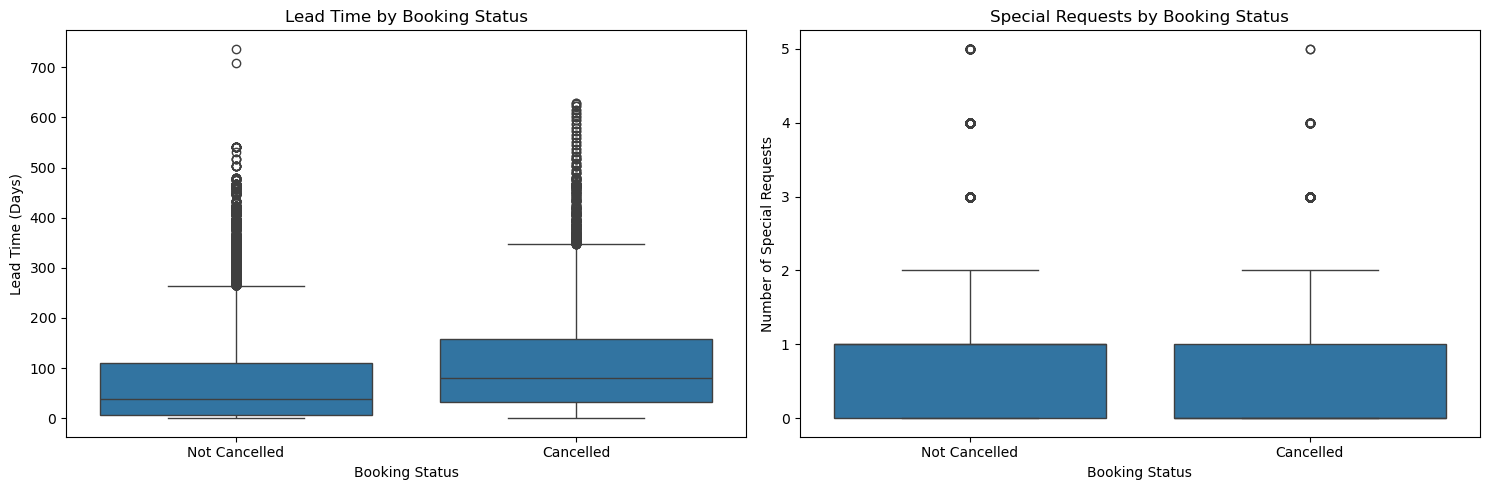

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=hotel_df,
    x="is_canceled",
    y="lead_time",
    ax=axes[0]
)

axes[0].set_title("Lead Time by Booking Status")
axes[0].set_xlabel("Booking Status")
axes[0].set_ylabel("Lead Time (Days)")
axes[0].set_xticklabels(["Not Cancelled", "Cancelled"])

sns.boxplot(
    data=hotel_df,
    x="is_canceled",
    y="total_of_special_requests",
    ax=axes[1]
)

axes[1].set_title("Special Requests by Booking Status")
axes[1].set_xlabel("Booking Status")
axes[1].set_ylabel("Number of Special Requests")
axes[1].set_xticklabels(["Not Cancelled", "Cancelled"])

plt.tight_layout()
plt.show()

### Observation

Bookings with longer lead times show greater variation in cancellation behavior. Customers who make more special requests generally have fewer cancelled bookings.

### Insight

Lead time and special requests are useful indicators of customer booking behavior and can contribute to identifying reservations with a higher likelihood of cancellation.

Seasonal Booking Trends

## Seasonal Booking Trends

### Why am I analyzing this?

Booking demand and room prices often vary throughout the year. In this section, I compare the average room price and booking volume across different months to identify seasonal trends.

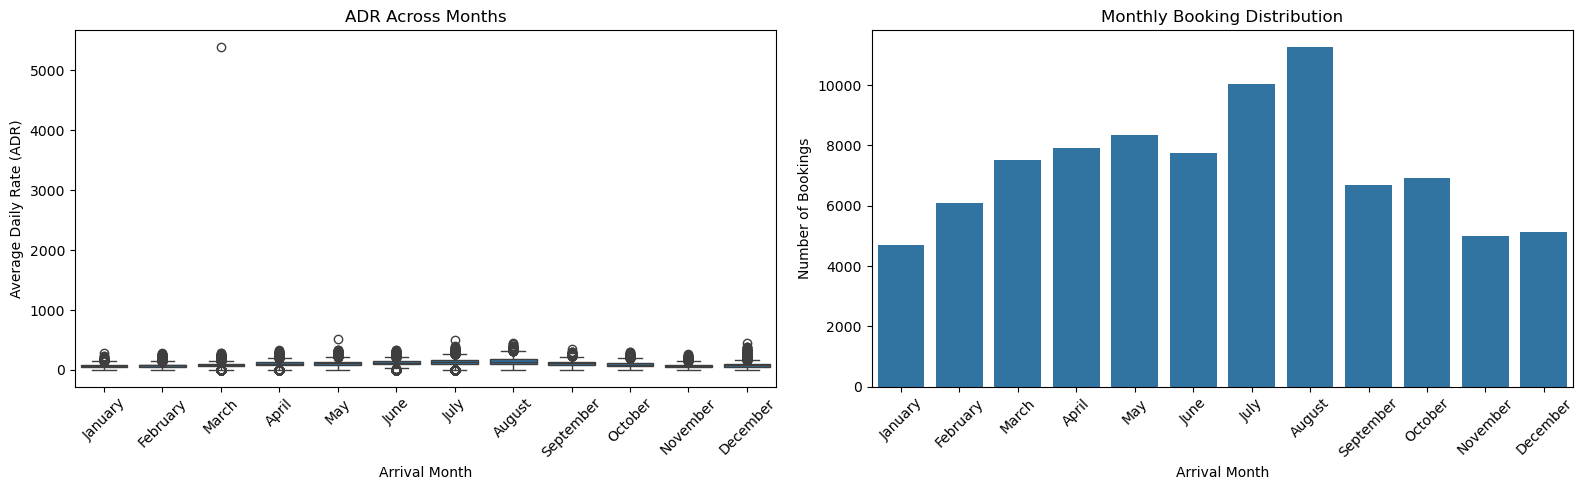

In [8]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=hotel_df,
    x="arrival_date_month",
    y="adr",
    order=month_order,
    ax=axes[0]
)

axes[0].set_title("ADR Across Months")
axes[0].set_xlabel("Arrival Month")
axes[0].set_ylabel("Average Daily Rate (ADR)")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(
    data=hotel_df,
    x="arrival_date_month",
    order=month_order,
    ax=axes[1]
)

axes[1].set_title("Monthly Booking Distribution")
axes[1].set_xlabel("Arrival Month")
axes[1].set_ylabel("Number of Bookings")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../visuals/monthly_booking_analysis.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Observation

Both booking volume and room prices vary across different months. Some months experience higher booking activity along with higher ADR values.

### Insight

Seasonal demand influences hotel occupancy and pricing. Identifying peak and off-peak periods can help optimize pricing strategies and resource planning.

Customer Stay Pattern

## Customer Stay Pattern

### Why am I analyzing this?

The duration of a guest's stay may differ depending on the hotel type. Comparing weekday and weekend stays helps understand how customers use different types of hotels.

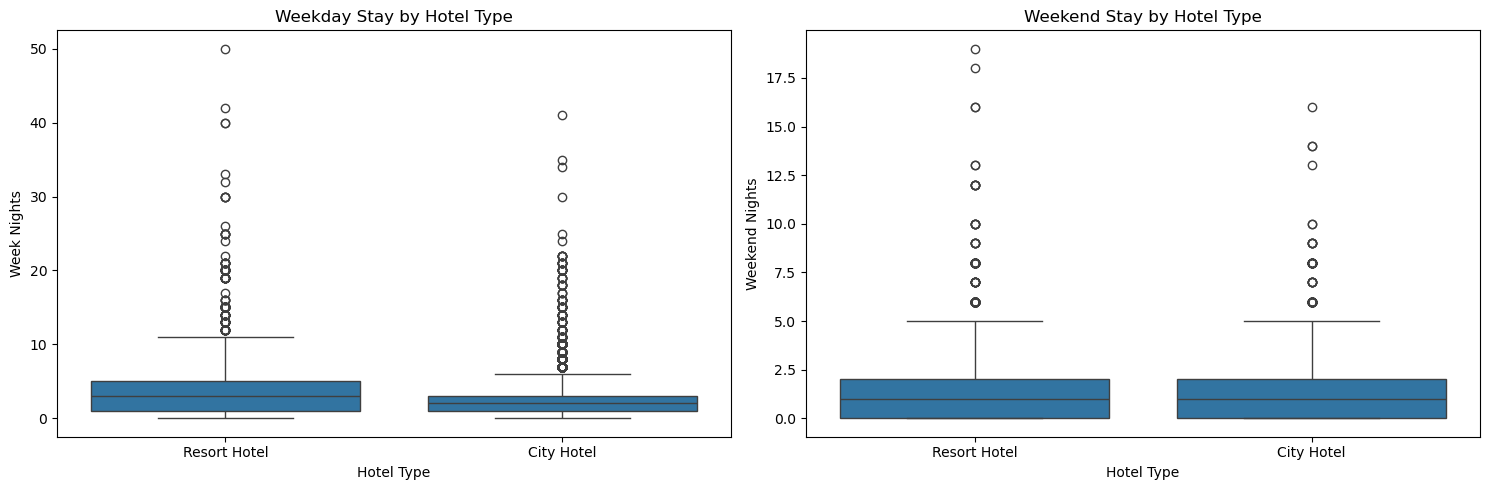

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=hotel_df,
    x="hotel",
    y="stays_in_week_nights",
    ax=axes[0]
)

axes[0].set_title("Weekday Stay by Hotel Type")
axes[0].set_xlabel("Hotel Type")
axes[0].set_ylabel("Week Nights")

sns.boxplot(
    data=hotel_df,
    x="hotel",
    y="stays_in_weekend_nights",
    ax=axes[1]
)

axes[1].set_title("Weekend Stay by Hotel Type")
axes[1].set_xlabel("Hotel Type")
axes[1].set_ylabel("Weekend Nights")

plt.tight_layout()
plt.show()

### Observation

The distribution of weekday and weekend stays differs between hotel types. Both hotel categories show variation in the number of nights booked by guests.

### Insight

Understanding stay patterns helps hotels estimate room occupancy, allocate resources efficiently, and develop pricing strategies based on guest stay duration.

# Summary

In this notebook, I explored the relationships between key features in the hotel booking dataset using bivariate analysis. I examined how booking cancellations vary across hotel types and deposit policies, compared room prices among different customer segments, analyzed customer booking behavior using lead time and special requests, identified seasonal trends in bookings and pricing, and studied stay patterns across hotel types. These analyses provide a deeper understanding of customer behavior and booking trends, forming a strong foundation for multivariate analysis and business recommendations.